## Preprocessing

In [0]:
# Core Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Model building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [0]:
df_spark = spark.read.format("delta").load("/Volumes/workspace/default/ai-enhanced_project/Cars_Datasets_2025_FE_delta3")
dfp = df_spark.toPandas()

In [0]:
dfp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1043 entries, 0 to 1042
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   company_names                  1043 non-null   object 
 1   cars_names                     1043 non-null   object 
 2   Engines                        1043 non-null   object 
 3   cc_battery_capacity            1043 non-null   int64  
 4   HorsePower                     1043 non-null   int64  
 5   total_speed                    1043 non-null   int64  
 6   performance_0_100_kmh          1043 non-null   float64
 7   cars_prices                    1043 non-null   int64  
 8   fuel_types                     1043 non-null   object 
 9   Seats                          1043 non-null   int64  
 10  Torque                         1043 non-null   int64  
 11  HP_per_CC                      1043 non-null   float64
 12  Price_per_HP                   1043 non-null   f

separate on categorical or numerical

In [0]:
cat_dfp = dfp.select_dtypes(include=['object'])
num_dfp = dfp.select_dtypes(include=['int64', 'float64'])

cat_col = cat_dfp.columns.tolist()
num_col = num_dfp.columns.tolist()

Encode categorical

In [0]:
le = LabelEncoder()

for col in cat_col:
    dfp[col] = le.fit_transform(dfp[col])

In [0]:
dfp.head()

,company_names,cars_names,Engines,cc_battery_capacity,HorsePower,total_speed,performance_0_100_kmh,cars_prices,fuel_types,Seats,Torque,HP_per_CC,Price_per_HP,HP_Acceleration_Effectiveness,Price_per_Seat,Cylinders,Price_Category
0,5,508,26,1200,77,165,10.5,13500,4,5,120,0.064167,175.324675,7.333333,2700.000000,4,0
1,22,380,296,2998,382,250,4.1,53900,4,2,500,0.127418,141.099476,93.170732,26950.000000,4,1
2,22,877,278,1998,205,226,6.4,27000,4,2,205,0.102603,131.707317,32.031250,13500.000000,4,2
3,22,876,278,2387,228,226,5.6,30000,4,4,250,0.095517,131.578947,40.714286,7500.000000,4,2
4,22,878,329,5663,381,220,6.7,85000,0,7,500,0.067279,223.097113,56.865672,12142.857143,8,1


scale numerical

In [0]:
scaler = StandardScaler()
for col in num_col:
    dfp[col] = scaler.fit_transform(dfp[[col]])

In [0]:
dfp.head()

,company_names,cars_names,Engines,cc_battery_capacity,HorsePower,total_speed,performance_0_100_kmh,cars_prices,fuel_types,Seats,Torque,HP_per_CC,Price_per_HP,HP_Acceleration_Effectiveness,Price_per_Seat,Cylinders,Price_Category
0,5,508,26,-0.723325,-1.392053,-1.011750,0.752626,-1.232108,4,-0.057802,-1.086396,-0.105335,-0.125106,-0.993446,-0.855035,-0.586194,0
1,22,380,296,0.348914,1.139708,1.198726,-1.318671,0.401526,4,-2.263444,0.513360,-0.096461,-0.794360,1.733441,2.098439,-0.586194,1
2,22,877,278,-0.247437,-0.329543,0.574591,-0.574298,-0.686215,4,-2.263444,-0.728556,-0.099942,-0.978018,-0.208841,0.460327,-0.586194,2
3,22,876,278,-0.015457,-0.138624,0.574591,-0.833210,-0.564906,4,-0.793016,-0.539111,-0.100937,-0.980528,0.067002,-0.270430,-0.586194,2
4,22,878,329,1.938189,1.131408,0.418558,-0.477206,1.659101,0,1.412626,0.513360,-0.104899,0.809056,0.580100,0.295036,2.287602,1


Correlation Matrix Overview (Too messy and overwhelming for final use)

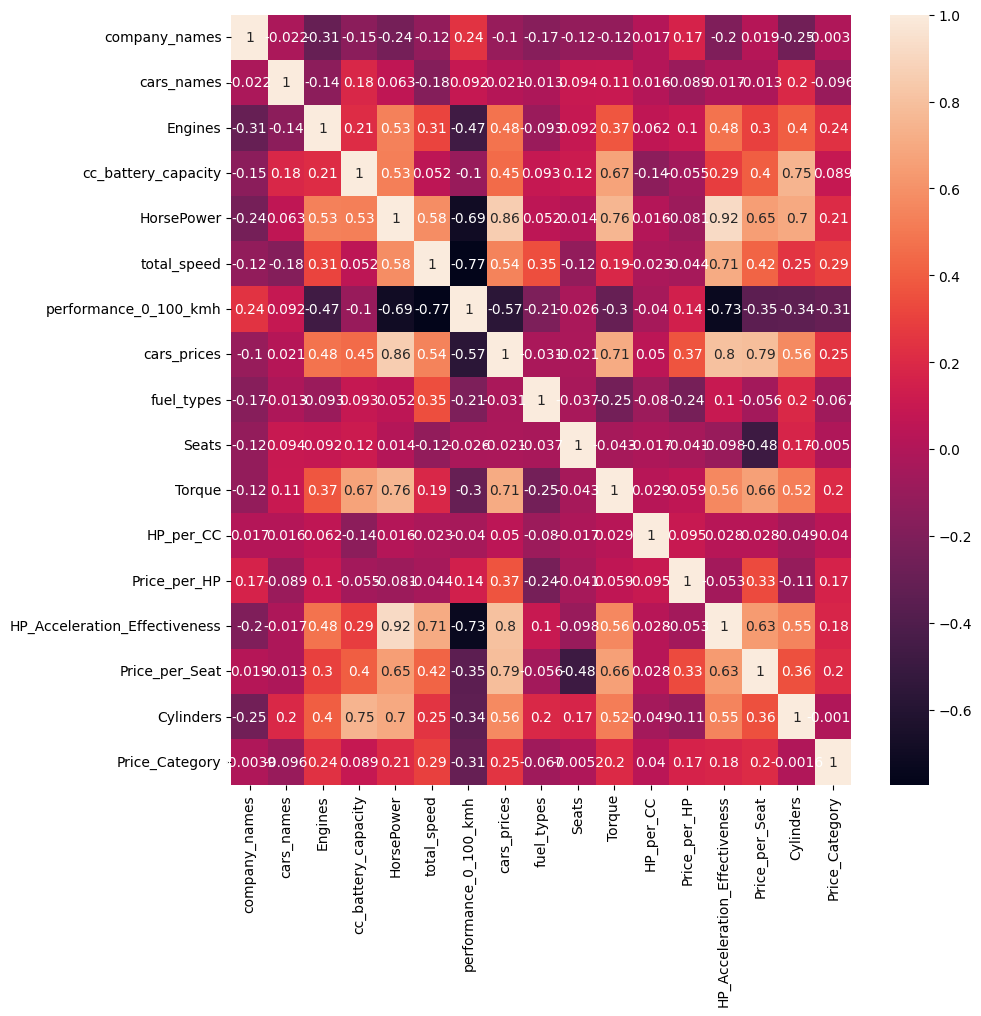

In [0]:
plt.figure(figsize=(10,10))
sns.heatmap(dfp.corr(), annot=True)
plt.show()

Drop columns that can cause bias or skewed data

In [0]:
cols_to_drop = ['cars_names', 'Engines', 'Price_Category', 'Price_per_Seat', 'Price_per_HP']
X = dfp.drop(columns=['cars_prices'] + cols_to_drop)
y = dfp["cars_prices"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (834, 11)
X_test:  (209, 11)
y_train: (834,)
y_test:  (209,)


In [0]:
X_train.head()

,company_names,cc_battery_capacity,HorsePower,total_speed,performance_0_100_kmh,fuel_types,Seats,Torque,HP_per_CC,HP_Acceleration_Effectiveness,Cylinders
544,10,0.707917,0.334525,-0.699683,0.137710,4,-0.057802,-0.105493,-0.103231,-0.173633,0.850704
256,23,-0.723922,-1.325646,-0.361610,0.752626,0,-0.057802,-0.707507,-0.104392,-0.969242,-1.304643
350,17,1.871994,1.521548,0.158502,-0.541934,4,1.412626,0.765953,-0.103522,0.865392,2.287602
60,2,-0.247437,0.085500,1.198726,-0.768482,4,-0.793016,0.092371,-0.096431,0.170287,-0.586194
928,16,0.051931,-0.528764,-0.361610,0.428986,4,1.412626,-0.560161,-0.104180,-0.621147,-0.586194


In [0]:
X_train_spark = spark.createDataFrame(X_train)
X_test_spark = spark.createDataFrame(X_test)
y_train_spark = spark.createDataFrame(y_train.to_frame())
y_test_spark = spark.createDataFrame(y_test.to_frame())

X_train_spark.write.format("delta").mode("overwrite").save("/Volumes/workspace/default/ai-enhanced_project/x_train_delta5")
X_test_spark.write.format("delta").mode("overwrite").save("/Volumes/workspace/default/ai-enhanced_project/x_test_delta5")
y_train_spark.write.format("delta").mode("overwrite").save("/Volumes/workspace/default/ai-enhanced_project/y_train_delta5")
y_test_spark.write.format("delta").mode("overwrite").save("/Volumes/workspace/default/ai-enhanced_project/y_test_delta")

X_train.to_csv("/Volumes/workspace/default/ai-enhanced_project/x_train.csv", index=False)
X_test.to_csv("/Volumes/workspace/default/ai-enhanced_project/x_test.csv", index=False)
y_train.to_csv("/Volumes/workspace/default/ai-enhanced_project/y_train.csv", index=False)
y_test.to_csv("/Volumes/workspace/default/ai-enhanced_project/y_test.csv", index=False)

In [0]:
dfp.to_csv("/Volumes/workspace/default/ai-enhanced_project/dfp.csv", index=False)